![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [1]:
#%pip install hvplot
#%pip install --dry-run 'numpy<2' numba

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_intervals import *
from glob import glob
import numpy as np
import os

In [4]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [5]:
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-15'                                        # time max for analysis

output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = 'DUACS'

stat_output_filename = f'{output_dir}/stat_ssh_4dvar_geos.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_ssh_4dvar_geos.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [6]:
list_of_file = sorted(glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/*/**/*2024*/2023/**/*.nc'))

ds_alg = xr.open_mfdataset(list_of_file)
ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)[["sla_filtered", "sla_unfiltered", "mdt", "lwe"]]
ds_alg['ssh'] = ds_alg.sla_unfiltered + ds_alg.mdt - ds_alg.lwe

## Sea Surface Height maps to evaluate

In [7]:
leadtime = 0

ds_maps = xr.open_dataset('/Odyssey/public/glorys/rec/glorys4_global_movpatch_softedge_fastrec_GPU_1patch/nrt_2023_global_4/test_data_{}.nc'.format(14+leadtime))

# select wednesdays (=2)
ds_maps = ds_maps.sel(time=ds_maps.time.dt.weekday == (2+leadtime)%7)
ds_maps["time"] = ds_maps["time"] + pd.to_timedelta(12, unit="h")

ds_maps = ds_maps.sel(time=slice(time_min, time_max)).rename({'out':'ssh', 'lat':'latitude', 'lon':'longitude'})

## Time restriction for methods with Intervals between leadtimes

In [8]:
# RESTRICT TIME TO 0.5 DAYS AROUND RECONSTRUCTED LEADTIMES
ds_alg = ds_alg.sel(time=restrict_time_alongtrack(ds_alg.time.values, ds_maps.time.values, days_offset=0.5))

## Very important manipulation in order to make DC21 notebooks work ! 

In [9]:
def ds_manip(ds):
    ds["longitude"] = (ds["longitude"] % 360).where(ds["longitude"] != 360, 0)
    lon_unique, index = np.unique(ds.coords["longitude"], return_index=True)
    ds = ds.isel(longitude=index)
    ds.latitude.attrs['units'] = 'degrees_north'
    ds.longitude.attrs['units'] = 'degrees_east'
    ds = ds.sortby(['time', 'longitude', 'latitude'])
    return ds

ds_maps = ds_manip(ds_maps)

# create an mdt dataset
mdt_maps = ds_manip(xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc").expand_dims({'time': ds_maps.time.values}, axis=0))

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [10]:
ds_interp = run_interpolation_plus(ds_maps, ds_alg, var_alongtrack='sla_unfiltered', var_rec='ssh', forecast_interval=True)

# interpolate mdt on the dataset as well
ds_interp_mdt = run_interpolation_plus(mdt_maps, ds_alg, var_alongtrack='sla_unfiltered', var_rec='mdt', out_var='mdt_interpolated', forecast_interval=True)

2025-01-29 09:03:29 INFO     fetch data from 2023-01-17 12:00:00 to 2023-02-07 12:00:00
2025-01-29 09:03:30 INFO     fetch data from 2023-01-31 12:00:00 to 2023-03-07 12:00:00
2025-01-29 09:03:30 INFO     fetch data from 2023-02-28 12:00:00 to 2023-04-04 12:00:00
2025-01-29 09:03:31 INFO     fetch data from 2023-03-28 12:00:00 to 2023-05-02 12:00:00
2025-01-29 09:03:31 INFO     fetch data from 2023-04-25 12:00:00 to 2023-06-06 12:00:00
2025-01-29 09:03:32 INFO     fetch data from 2023-05-30 12:00:00 to 2023-07-04 12:00:00
2025-01-29 09:03:33 INFO     fetch data from 2023-06-27 12:00:00 to 2023-08-01 12:00:00
2025-01-29 09:03:33 INFO     fetch data from 2023-07-25 12:00:00 to 2023-09-05 12:00:00
2025-01-29 09:03:34 INFO     fetch data from 2023-08-29 12:00:00 to 2023-09-05 12:00:00
2025-01-29 09:03:35 INFO     fetch data from 2023-01-17 12:00:00 to 2023-02-07 12:00:00
2025-01-29 09:03:35 INFO     fetch data from 2023-01-31 12:00:00 to 2023-03-07 12:00:00
2025-01-29 09:03:35 INFO     fet

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [11]:
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered'] + ds_interp_mdt['mdt_interpolated']
ds_interp['sla_filtered'] = ds_interp['sla_filtered'] + ds_interp_mdt['mdt_interpolated']
ds_interp['msla_interpolated'] = ds_interp['ssh_interpolated']
ds_interp = ds_interp.dropna('time')

In [12]:
m_var, s_var = ds_interp.sla_unfiltered.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
print('original ssh: {:0.4f} | {:0.4f}'.format(m_var, s_var))
m_var, s_var = ds_interp.msla_interpolated.pipe(lambda da: (da.mean().values.item(), da.std().values.item()))
print('interpolated ssh: {:0.4f} | {:0.4f}'.format(m_var, s_var))

original ssh: 0.4174 | 0.6927
interpolated ssh: 0.4108 | 0.6812


2025-01-24 14:12:51 INFO     Compute mapping error all scales
2025-01-24 14:12:51 INFO     Compute mapping error for scales between 65.0 and 500.0 km
Total RMSE= 0.073872999293539 m
Total RMSE score= 0.9087194550609237 m
2025-01-24 14:13:01 INFO     Compute binning statistics
2025-01-24 14:13:03 INFO     Compute statistics by oceanic regime


## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [13]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename, method_name, freq_out='1D', land_sea_mask='/Odyssey/public/data_challenge_ssh_ose/data/sad/land_water_mask_60.nc', variance_ssh='/Odyssey/public/data_challenge_ssh_ose/data/sad/variance_cmems_dt_allsat.nc', distance_to_nearest_coast='/Odyssey/public/data_challenge_ssh_ose/data/sad/distance_to_nearest_coastline_60.nc')

2025-01-29 09:03:36 INFO     Compute mapping error all scales
2025-01-29 09:03:36 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.07505422134116543 m
Total RMSE score= 0.9072847889345523 m


2025-01-29 09:03:46 INFO     Compute binning statistics
2025-01-29 09:03:48 INFO     Compute statistics by oceanic regime
2025-01-29 09:04:09 INFO     Stat file saved as: ../results/stat_ssh_4dvar_geos.nc


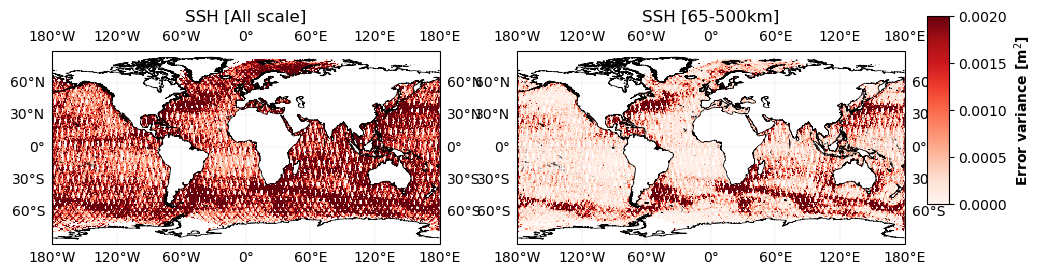

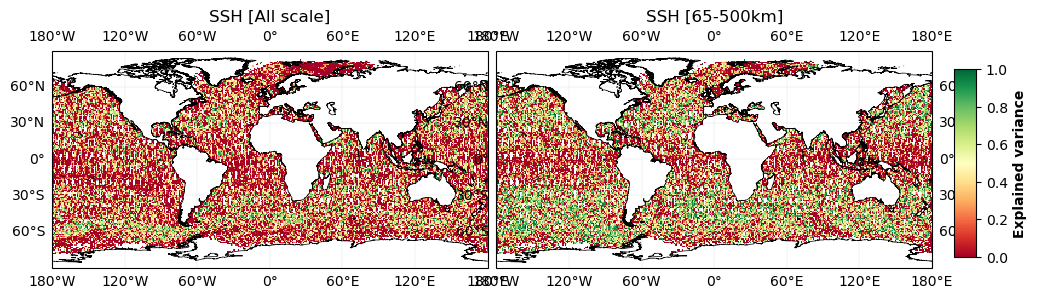

In [14]:
plot_stat_score_map_png(stat_output_filename)

In [15]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [16]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.005610,0.075395,0.906864,0.351091,0.830103,0.906864,0.001289,0.035905,0.906864,0.002519,0.050191,0.906864,0.984021,0.488243
offshore_highvar,0.027348,0.165762,0.795233,0.320812,0.777283,0.795233,0.011531,0.107388,0.795233,0.026284,0.162968,0.795233,0.914754,0.561303
offshore_lowvar,0.003814,0.062161,0.923212,0.519114,0.804647,0.923212,0.000970,0.031140,0.923212,0.002318,0.048175,0.923212,0.992654,0.581727
equatorial_band,0.003600,0.062195,0.923170,0.057856,0.881892,0.923170,0.000580,0.024077,0.923170,0.000641,0.025354,0.923170,0.937776,0.095719
arctic,0.004077,0.063866,0.921105,0.014268,0.271032,0.921105,0.000647,0.025449,0.921105,0.000881,0.029685,0.921105,0.714229,0.264702
antarctic,0.006499,0.081797,0.898955,0.004188,1.205916,0.898955,0.002044,0.045202,0.898955,0.000623,0.024987,0.898955,-0.551728,-2.277561


## 2.3 Compute Spectral scores

In [17]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2025-01-29 09:04:34 INFO     Segment computation...


2025-01-29 09:04:36 INFO     Spectral analysis...
2025-01-29 09:08:44 INFO     Saving ouput...
2025-01-29 09:09:04 INFO     PSD file saved as: ../results/psd_ssh_4dvar_geos.nc


Averaged effective resolution: 345.92049576510914 km


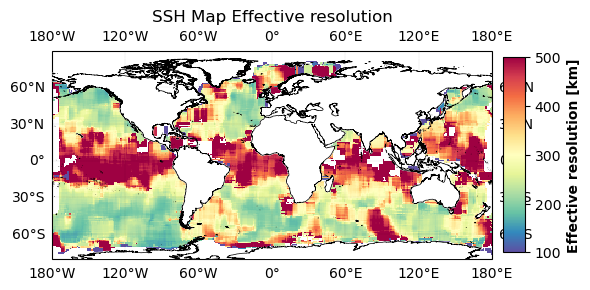

In [18]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

In [19]:
#plot_psd_scores(psd_output_filename)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box